In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv('/Users/ruch/Desktop/ML-Engineer/Core/Machine Learning/Data/3-customersatisfaction.csv')
df

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365
...,...,...,...
95,95,2.055072,8.686851
96,96,0.864149,2.901486
97,97,-1.586101,0.786207
98,98,1.558528,5.447475


In [4]:
df.drop("Unnamed: 0", axis=1, inplace=True) # drop the unnamed column which is the index column axis=1 for column, axis=0 for row, inplace=True to make the change in the original dataframe

In [5]:
df.shape

(100, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Satisfaction  100 non-null    float64
 1   Incentive              100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [7]:
df.describe()

,Customer Satisfaction,Incentive
count,100.000000,100.000000
mean,-0.005427,3.445220
std,1.721792,2.911818
min,-2.992863,-1.068081
25%,-1.431357,1.471341
50%,0.109167,2.748839
75%,1.421119,4.739113
max,2.986736,11.000056


In [8]:
df.isnull().sum()

Customer Satisfaction    0
Incentive                0
dtype: int64

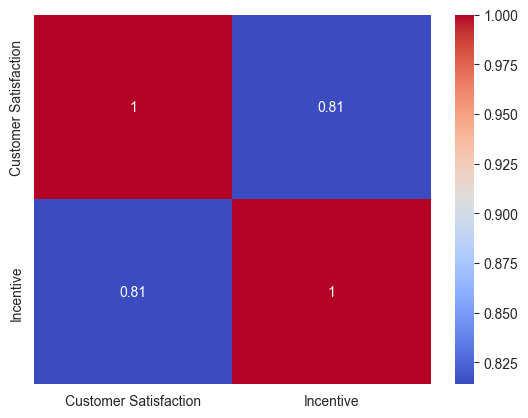

In [9]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

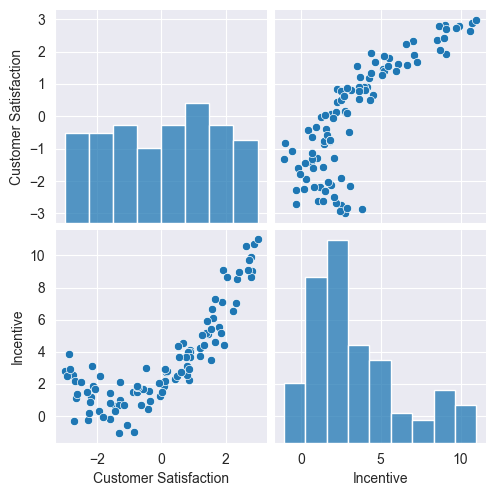

In [10]:
sns.pairplot(df)
plt.show()

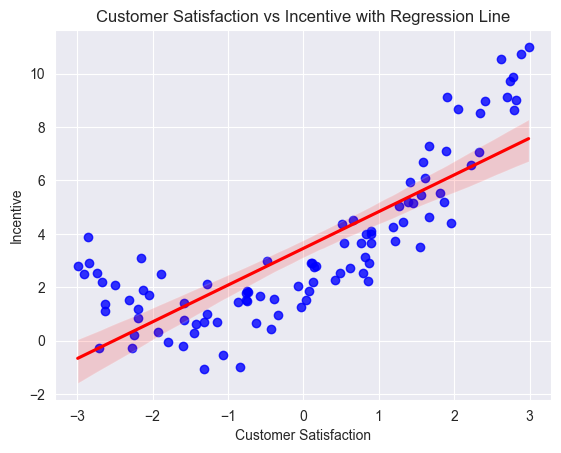

In [11]:
sns.regplot(x=df['Customer Satisfaction'], y=df['Incentive'], data=df, scatter_kws={"color": "blue"}, line_kws={"color": "red"}) # scatter_kws for scatter plot color, line_kws for regression line color. It is try to draw how it can be the best fit line with liear regression is not good
plt.xlabel('Customer Satisfaction')
plt.ylabel('Incentive')
plt.title('Customer Satisfaction vs Incentive with Regression Line')
plt.show()

In [12]:
# independent (input) and dependent (output) features

X = df[['Customer Satisfaction']] # 2D array for single feature
y = df['Incentive'] # 1D array

In [13]:
# train - test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [14]:
X_train.head()

,Customer Satisfaction
15,-1.602837
40,1.321758
96,0.864149
9,-2.631664
72,-2.243889


In [15]:
# Standardize the data

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit and transform the training data
X_test = scaler.transform(X_test) # only transform the test data

In [16]:
# Training the Model with Linear Regression

regression = LinearRegression()
regression.fit(X_train, y_train) # training the model with training data X_train girdileri ve y_train çıktılarını veriyor bunu model öğreniyor

LinearRegression()

In [17]:
# Predicting the Test Set Results

y_pred = regression.predict(X_test)
y_pred

array([ 7.00796705,  7.33494167,  4.45022986,  0.94161176,  6.48720674,
       -0.43467098,  5.54324884,  2.49785688,  7.08572662,  1.78776316,
        4.56336431,  7.06630992,  2.46163838,  2.95088708,  0.59758212,
        1.60080541,  3.67105636,  2.63115814,  4.09147519,  0.04213559,
        1.96587658,  5.87521676,  4.61493043,  0.80071287,  2.06267125])

In [18]:
score = r2_score(y_test, y_pred)
score # R-squared value is bad for linear regression

0.7336057174204197

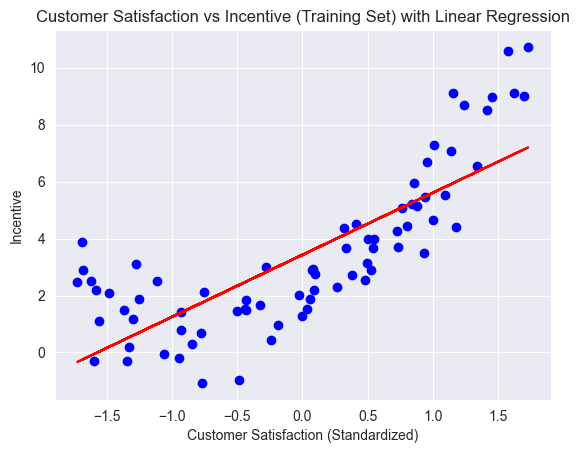

In [19]:
plt.scatter(X_train, y_train, color='blue') # training data points
plt.plot(X_train, regression.predict(X_train), color='red') # prediction line on training data by learned model with linear regression
plt.xlabel('Customer Satisfaction (Standardized)')
plt.ylabel('Incentive')
plt.title('Customer Satisfaction vs Incentive (Training Set) with Linear Regression')
plt.show()

In [20]:
# Training the Model with Polynomial Regression because linear regression is not good for this data

In [21]:
poly = PolynomialFeatures() # default degree=2, it will create polynomial features up to degree 2 (quadratic) and include_bias = True

In [22]:
X_train_poly = poly.fit_transform(X_train) # fit and transform the training data to polynomial features
X_test_poly = poly.transform(X_test) # only transform the test data to polynomial features

In [23]:
X_train_poly

array([[ 1.00000000e+00, -9.42567362e-01,  8.88433233e-01],
       [ 1.00000000e+00,  8.00146426e-01,  6.40234303e-01],
       [ 1.00000000e+00,  5.27465610e-01,  2.78219970e-01],
       [ 1.00000000e+00, -1.55562707e+00,  2.41997558e+00],
       [ 1.00000000e+00, -1.32455885e+00,  1.75445615e+00],
       [ 1.00000000e+00,  8.76394518e-01,  7.68067352e-01],
       [ 1.00000000e+00,  5.04979244e-01,  2.55004036e-01],
       [ 1.00000000e+00, -1.27422817e+00,  1.62365743e+00],
       [ 1.00000000e+00,  7.22242075e-01,  5.21633615e-01],
       [ 1.00000000e+00,  4.95513202e-01,  2.45533334e-01],
       [ 1.00000000e+00, -7.68924246e-01,  5.91244497e-01],
       [ 1.00000000e+00, -1.47839145e+00,  2.18564129e+00],
       [ 1.00000000e+00,  1.33497358e+00,  1.78215446e+00],
       [ 1.00000000e+00,  7.66376541e-01,  5.87333002e-01],
       [ 1.00000000e+00, -4.41019822e-01,  1.94498483e-01],
       [ 1.00000000e+00, -3.28526016e-01,  1.07929343e-01],
       [ 1.00000000e+00, -4.35259198e-01

In [24]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train) # training the model with training data X_train girdileri ve y_train çıktılarını veriyor bunu model öğreniyor

LinearRegression()

In [25]:
y_pred = regression.predict(X_test_poly)
y_pred

array([ 9.90484756, 11.03106568,  3.39972537,  1.12449949,  8.24905523,
        2.33197439,  5.67954704,  1.1846304 , 10.16662645,  0.96951724,
        3.60107445, 10.10090595,  1.16603498,  1.48645789,  1.31540767,
        0.96526588,  2.23017214,  1.26012866,  2.81411694,  1.77968978,
        0.99387794,  6.51972505,  3.69550116,  1.19374697,  1.01542821])

In [26]:
score = r2_score(y_test, y_pred)
score # R-squared value is good for polynomial regression

0.9492732221578819

In [27]:
regression.coef_

array([0.        , 2.40960367, 1.48518101])

In [28]:
regression.intercept_

1.9416021619741661

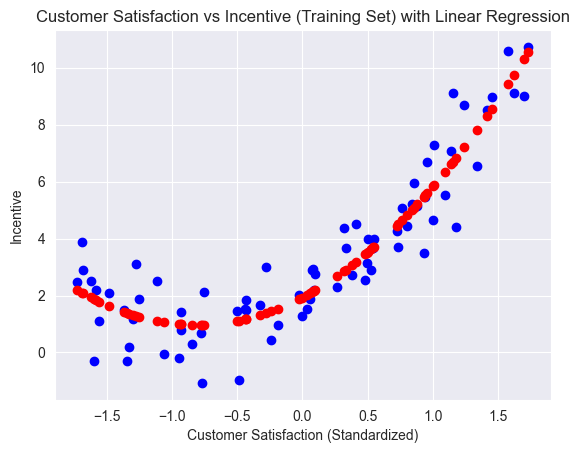

In [29]:
plt.scatter(X_train, y_train, color='blue') # training data points
plt.scatter(X_train, regression.predict(X_train_poly), color='red') # prediction line on training data by learned model with polynomial regression
plt.xlabel('Customer Satisfaction (Standardized)')
plt.ylabel('Incentive')
plt.title('Customer Satisfaction vs Incentive (Training Set) with Linear Regression')
plt.show()

In [30]:
poly = PolynomialFeatures(degree=3) # degree=3 cubic

In [31]:
X_train_poly_d3 = poly.fit_transform(X_train) # fit and transform the training data to polynomial features
X_test_poly_d3 = poly.transform(X_test) # only transform the test data to polynomial

In [32]:
X_train_poly_d3

array([[ 1.00000000e+00, -9.42567362e-01,  8.88433233e-01,
        -8.37408169e-01],
       [ 1.00000000e+00,  8.00146426e-01,  6.40234303e-01,
         5.12281190e-01],
       [ 1.00000000e+00,  5.27465610e-01,  2.78219970e-01,
         1.46751466e-01],
       [ 1.00000000e+00, -1.55562707e+00,  2.41997558e+00,
        -3.76457951e+00],
       [ 1.00000000e+00, -1.32455885e+00,  1.75445615e+00,
        -2.32388041e+00],
       [ 1.00000000e+00,  8.76394518e-01,  7.68067352e-01,
         6.73130017e-01],
       [ 1.00000000e+00,  5.04979244e-01,  2.55004036e-01,
         1.28771745e-01],
       [ 1.00000000e+00, -1.27422817e+00,  1.62365743e+00,
        -2.06891003e+00],
       [ 1.00000000e+00,  7.22242075e-01,  5.21633615e-01,
         3.76745745e-01],
       [ 1.00000000e+00,  4.95513202e-01,  2.45533334e-01,
         1.21665008e-01],
       [ 1.00000000e+00, -7.68924246e-01,  5.91244497e-01,
        -4.54622229e-01],
       [ 1.00000000e+00, -1.47839145e+00,  2.18564129e+00,
      

In [33]:
regression = LinearRegression()

In [34]:
regression.fit(X_train_poly_d3, y_train)

LinearRegression()

In [35]:
y_pred = regression.predict(X_test_poly_d3)
y_pred

array([ 9.67599581, 10.65195156,  3.48950781,  1.0145876 ,  8.19613198,
        2.61725983,  5.78039509,  1.06942616,  9.90497895,  0.81659559,
        3.69854312,  9.8476153 ,  1.04777698,  1.41623647,  1.26082276,
        0.812125  ,  2.24354736,  1.15695293,  2.87285124,  1.87236279,
        0.84539676,  6.58765565,  3.79607838,  1.10346859,  0.87092616])

In [36]:
score = r2_score(y_test, y_pred) # score hesaplarken y_test ve y_pred kullanırsın çünkü y_test gerçek değerlerdir y_pred ise modelin tahmin ettiği değerlerdir
score # R-squared value is better for degree=3 polynomial regression

0.9530672866075287

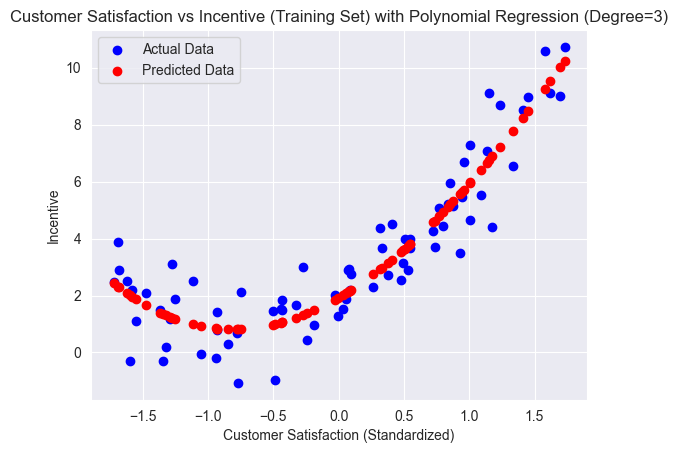

In [37]:
plt.scatter(X_train, y_train, color='blue', label='Actual Data') # training data points
plt.scatter(X_train, regression.predict(X_train_poly_d3), color='red', label='Predicted Data') # prediction line on training data by learned model with polynomial regression
plt.xlabel('Customer Satisfaction (Standardized)')
plt.ylabel('Incentive')
plt.title('Customer Satisfaction vs Incentive (Training Set) with Polynomial Regression (Degree=3)')
plt.legend()
plt.show()

In [38]:
# new data
new_df = pd.read_csv("Data/3-newdatas.csv")
new_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Data/3-newdatas.csv'

In [39]:
new_df.rename(columns= {"0" : "Customer Satisfaction"}, inplace=True) # x_new = new_df[["Customer Satisfaction"]]
new_df.head()

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397


In [40]:
X_new = new_df[["Customer Satisfaction"]]
X_new

,Customer Satisfaction
0,-3.000000
1,-2.969849
2,-2.939698
3,-2.909548
4,-2.879397
...,...
195,2.879397
196,2.909548
197,2.939698
198,2.969849


In [41]:
X_new = scaler.fit_transform(X_new) # scale the new data
X_new

array([[-1.7234121 ],
       [-1.70609137],
       [-1.68877065],
       [-1.67144992],
       [-1.6541292 ],
       [-1.63680847],
       [-1.61948775],
       [-1.60216702],
       [-1.5848463 ],
       [-1.56752558],
       [-1.55020485],
       [-1.53288413],
       [-1.5155634 ],
       [-1.49824268],
       [-1.48092195],
       [-1.46360123],
       [-1.4462805 ],
       [-1.42895978],
       [-1.41163905],
       [-1.39431833],
       [-1.3769976 ],
       [-1.35967688],
       [-1.34235616],
       [-1.32503543],
       [-1.30771471],
       [-1.29039398],
       [-1.27307326],
       [-1.25575253],
       [-1.23843181],
       [-1.22111108],
       [-1.20379036],
       [-1.18646963],
       [-1.16914891],
       [-1.15182818],
       [-1.13450746],
       [-1.11718674],
       [-1.09986601],
       [-1.08254529],
       [-1.06522456],
       [-1.04790384],
       [-1.03058311],
       [-1.01326239],
       [-0.99594166],
       [-0.97862094],
       [-0.96130021],
       [-0

In [42]:
X_new_poly = poly.transform(X_new) # transform the new data to polynomial features
X_new_poly

array([[ 1.00000000e+00, -1.72341210e+00,  2.97014925e+00,
        -5.11879115e+00],
       [ 1.00000000e+00, -1.70609137e+00,  2.91074777e+00,
        -4.96600165e+00],
       [ 1.00000000e+00, -1.68877065e+00,  2.85194630e+00,
        -4.81628320e+00],
       [ 1.00000000e+00, -1.67144992e+00,  2.79374484e+00,
        -4.66960460e+00],
       [ 1.00000000e+00, -1.65412920e+00,  2.73614340e+00,
        -4.52593469e+00],
       [ 1.00000000e+00, -1.63680847e+00,  2.67914198e+00,
        -4.38524229e+00],
       [ 1.00000000e+00, -1.61948775e+00,  2.62274057e+00,
        -4.24749622e+00],
       [ 1.00000000e+00, -1.60216702e+00,  2.56693917e+00,
        -4.11266530e+00],
       [ 1.00000000e+00, -1.58484630e+00,  2.51173779e+00,
        -3.98071835e+00],
       [ 1.00000000e+00, -1.56752558e+00,  2.45713643e+00,
        -3.85162419e+00],
       [ 1.00000000e+00, -1.55020485e+00,  2.40313508e+00,
        -3.72535165e+00],
       [ 1.00000000e+00, -1.53288413e+00,  2.34973374e+00,
      

In [43]:
y_new_pred = regression.predict(X_new_poly)
y_new_pred

array([ 2.43788325,  2.3748753 ,  2.31318399,  2.25280494,  2.19373381,
        2.13596624,  2.07949786,  2.02432432,  1.97044126,  1.91784432,
        1.86652914,  1.81649137,  1.76772664,  1.72023059,  1.67399888,
        1.62902713,  1.58531099,  1.54284611,  1.50162812,  1.46165266,
        1.42291538,  1.38541192,  1.34913791,  1.31408901,  1.28026084,
        1.24764906,  1.21624931,  1.18605721,  1.15706843,  1.12927859,
        1.10268335,  1.07727833,  1.05305919,  1.03002156,  1.00816109,
        0.98747341,  0.96795417,  0.94959901,  0.93240358,  0.9163635 ,
        0.90147443,  0.887732  ,  0.87513186,  0.86366964,  0.853341  ,
        0.84414156,  0.83606698,  0.82911289,  0.82327493,  0.81854875,
        0.81492999,  0.81241429,  0.81099729,  0.81067462,  0.81144195,
        0.81329489,  0.8162291 ,  0.82024022,  0.82532389,  0.83147574,
        0.83869143,  0.84696659,  0.85629686,  0.86667789,  0.87810531,
        0.89057478,  0.90408192,  0.91862238,  0.93419181,  0.95

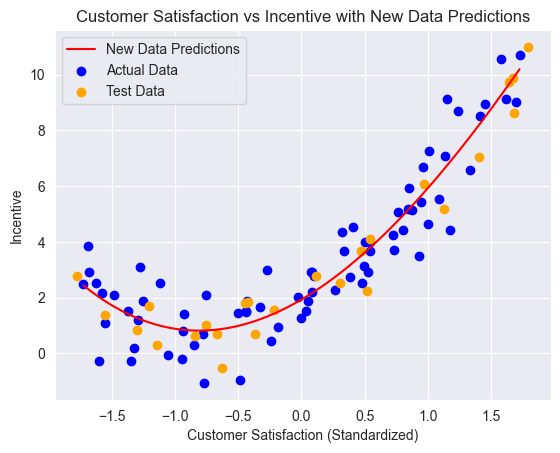

In [46]:
plt.plot(X_new, y_new_pred, color='red', label='New Data Predictions') # prediction line on new data by learned model with polynomial regression
plt.scatter(X_train, y_train, color='blue', label='Actual Data')
plt.scatter(X_test, y_test, color='orange', label='Test Data')
plt.xlabel('Customer Satisfaction (Standardized)')
plt.ylabel('Incentive')
plt.title('Customer Satisfaction vs Incentive with New Data Predictions')
plt.legend()
plt.show()

In [75]:
# pipeline

def poly_regression(degree):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly_features', PolynomialFeatures(degree=degree)),
        ('regression', LinearRegression())
    ])

    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print("R-squared value from pipeline:", score)

    y_pred_new = pipeline.predict(X_new)
    plt.plot(X_new, y_pred_new, color='red', label='New Data Predictions') # prediction line on new data by learned model with polynomial regression
    plt.scatter(X_train, y_train, color='blue', label='Actual Data')
    plt.scatter(X_test, y_test, color='orange', label='Test Data')
    plt.xlabel('Customer Satisfaction (Standardized)')
    plt.ylabel('Incentive')
    plt.title('Customer Satisfaction vs Incentive with New Data Predictions')
    plt.legend()
    plt.show()

    return score

Polynomial Regression with Degree=2
R-squared value from pipeline: 0.9492732221578819


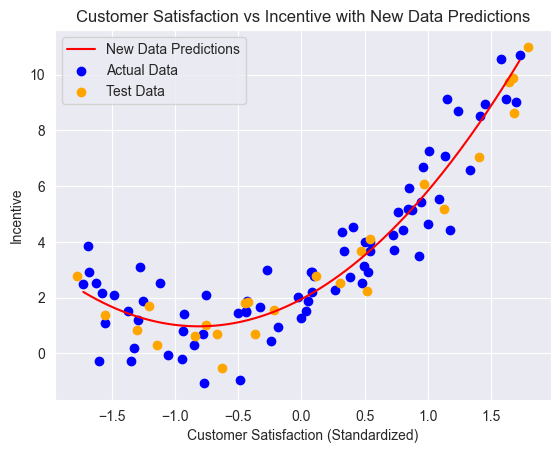

Polynomial Regression with Degree=3
R-squared value from pipeline: 0.9530672866075287


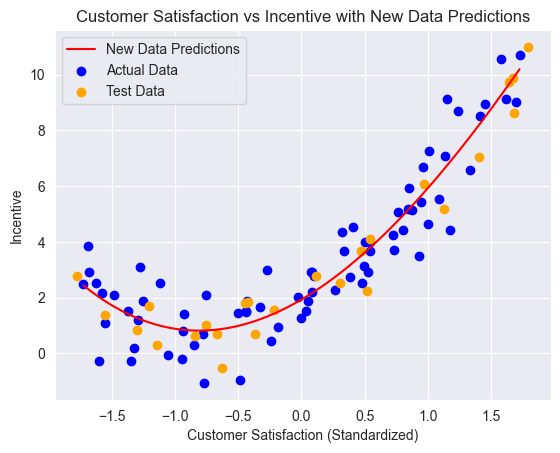

0.9530672866075287

In [76]:
print("Polynomial Regression with Degree=2")
poly_regression(2)
print("Polynomial Regression with Degree=3")
poly_regression(3)

Polynomial Regression with Degree=1
R-squared value from pipeline: 0.7336057174204198


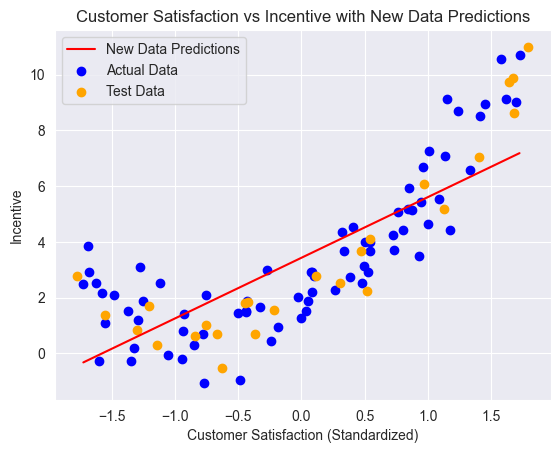

Polynomial Regression with Degree=2
R-squared value from pipeline: 0.9492732221578819


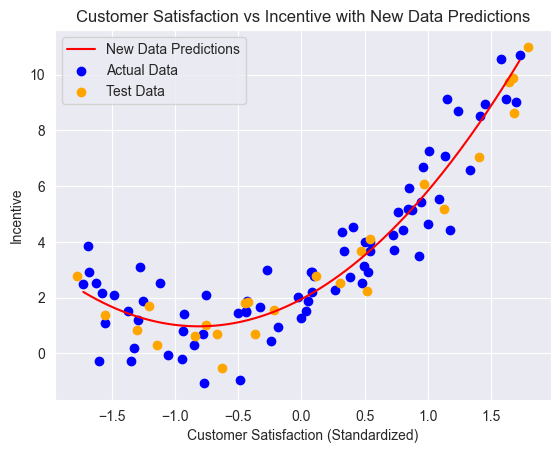

Polynomial Regression with Degree=3
R-squared value from pipeline: 0.9530672866075287


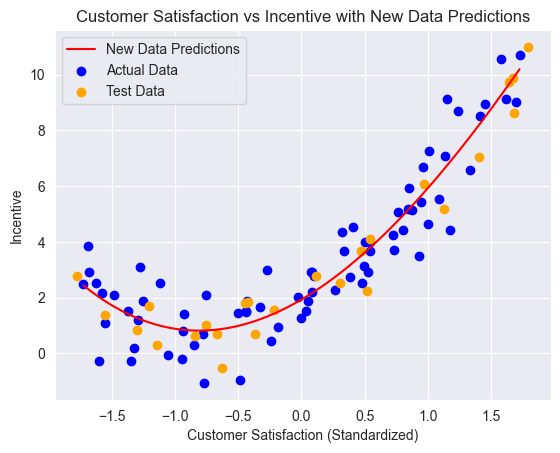

Polynomial Regression with Degree=4
R-squared value from pipeline: 0.9538943995741952


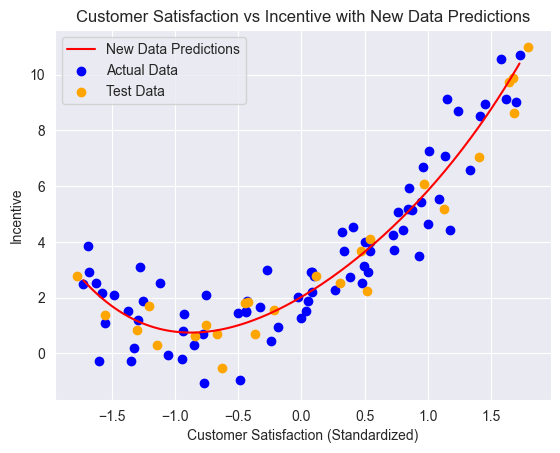

Polynomial Regression with Degree=5
R-squared value from pipeline: 0.952932549516372


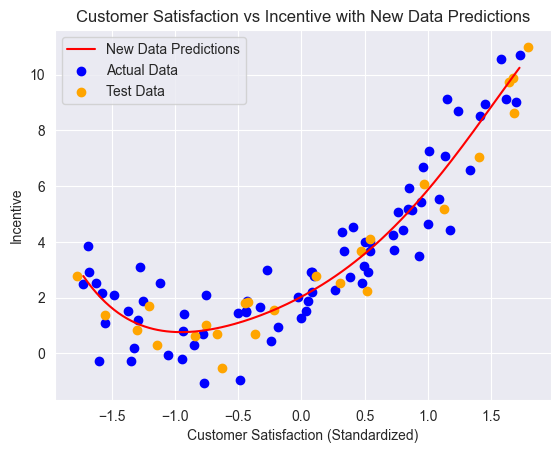

Polynomial Regression with Degree=6
R-squared value from pipeline: 0.9521156904336585


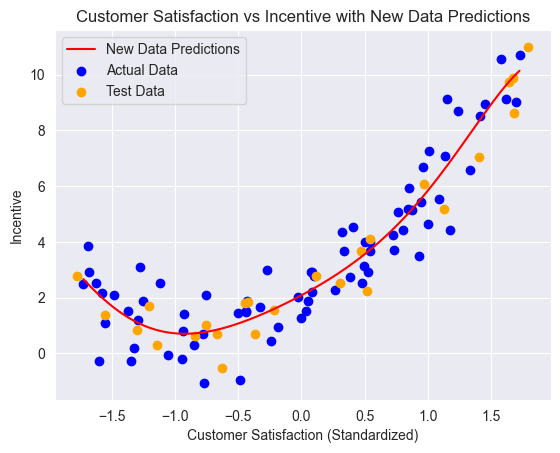

Polynomial Regression with Degree=7
R-squared value from pipeline: 0.9430536236525743


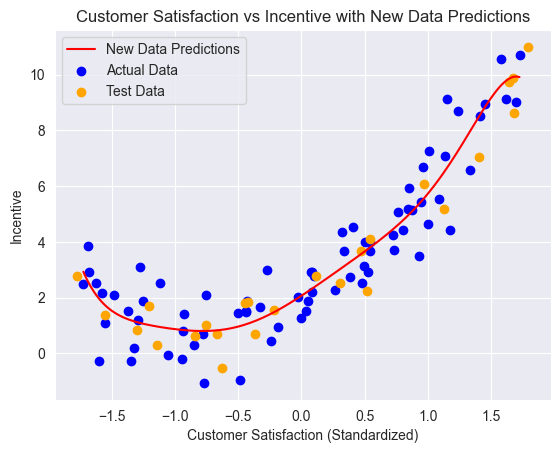

Polynomial Regression with Degree=8
R-squared value from pipeline: 0.9439215160067808


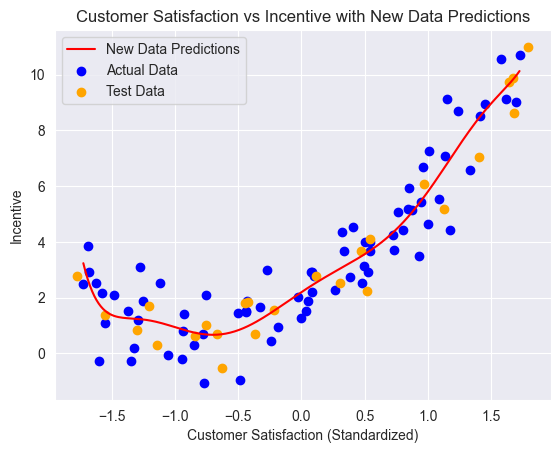

Polynomial Regression with Degree=9
R-squared value from pipeline: 0.9370362110792465


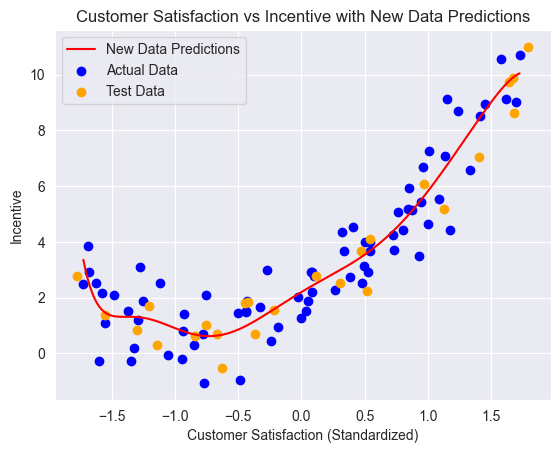

Polynomial Regression with Degree=10
R-squared value from pipeline: 0.9354201230519144


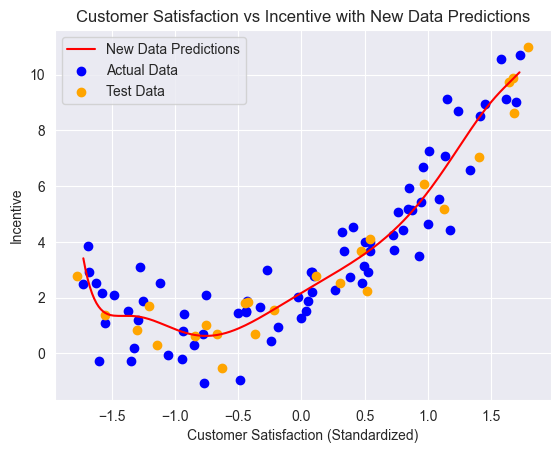

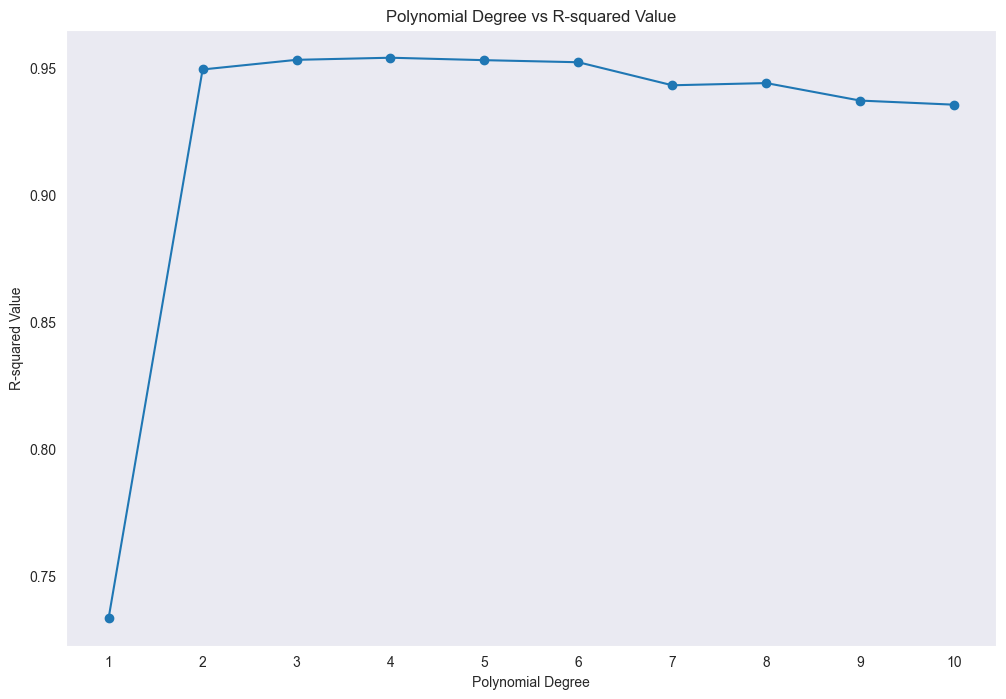

In [78]:
degree_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
degree_score_list = []

for i in degree_list:
    print(f"Polynomial Regression with Degree={i}")
    #poly_regression(i)
    degree_score_list.append((i, poly_regression(i)))

#degree_score_list

plt.subplots(figsize=(12, 8))
plt.plot(*zip(*degree_score_list), marker='o') # unzip the list of tuples into two lists for x and y axis
plt.xlabel('Polynomial Degree')
plt.ylabel('R-squared Value')
plt.title('Polynomial Degree vs R-squared Value')
plt.xticks(degree_list)
plt.grid()
plt.show()